# 2-практика · Confusion Matrix жана метрикалар

**Кыргыз Республикасынын Эсептөө палатасы · AI тренинги · 1-күн**

1-дептерде моделибиз **87% тактыкка** жетти. Бул жетиштүүбү?
Азыр бул суроого **аудитордун көзү менен** карайбыз.

## 0-кадам · Даярдык (1-дептерди кайталайбыз)

Бул блок 1-дептердеги ишти тез кайталайт: маалымат + модель. Жөн гана иштетиңиз.

In [1]:
%pip install -q pandas scikit-learn matplotlib

In [7]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(12)   # seed — жыйынтык ар дайым бирдей болушу үчүн
n = 250

df = pd.DataFrame({
    "аймак": rng.choice(["Бишкек","Ош","Чүй","Ысык-Көл","Жалал-Абад","Нарын","Талас","Баткен"], n),
    "тип": rng.choice(["мектеп","оорукана","муниципалдык ишкана","мамлекеттик мекеме","айыл өкмөтү"], n),
    "бюджет_млн_сом": np.round(rng.uniform(5, 500, n), 1),
    "мурунку_бузуулар": rng.poisson(1.4, n).clip(0, 8),
    "бир_булак_пайыз": np.round(rng.beta(2, 4, n) * 90, 0),
    "кечигүү_күн": rng.poisson(8, n).clip(0, 60),
    "четтөө_пайыз": np.round(np.abs(rng.normal(8, 7, n)).clip(0, 30), 1),
})

# Жашыруун эреже (модель муну билбейт — өзү табышы керек!)
score = (1.15*(df["мурунку_бузуулар"] >= 3)
       + 0.85*(df["бир_булак_пайыз"] > 50)
       + 0.65*(df["четтөө_пайыз"] > 15)
       + 0.35*(df["кечигүү_күн"] > 20)
       + rng.normal(0, 0.42, n))
df["тобокелдик"] = np.where(score > 1.05, "Жогорку", "Төмөн")

print("Даяр! Мекемелердин саны:", len(df))

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

белгилер = ["бюджет_млн_сом", "мурунку_бузуулар", "бир_булак_пайыз", "кечигүү_күн", "четтөө_пайыз"]
X = df[белгилер]
y = (df["тобокелдик"] == "Жогорку").astype(int)   # 1 = Жогорку, 0 = Төмөн

X_окутуу, X_сынак, y_окутуу, y_сынак = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

модель = DecisionTreeClassifier(max_depth=3, random_state=42)
модель.fit(X_окутуу, y_окутуу)

print("Окутууга берилди:", len(X_окутуу), "мекеме")
print("Сынакка катышты: ", len(X_сынак), "мекеме")

божомол = модель.predict(X_сынак)
ыктымалдуулук = модель.predict_proba(X_сынак)[:, 1]
print("Модель даяр ✓")

Даяр! Мекемелердин саны: 250
Окутууга берилди: 187 мекеме
Сынакка катышты:  63 мекеме
Модель даяр ✓


## 1-кадам · Confusion Matrix — «Каталар матрицасы»

Тактык бир эле сан. Confusion Matrix болсо **төрт** санды көрсөтөт — ката кайсы жакка кеткенин:

|  | Модель: Төмөн | Модель: Жогорку |
|---|---|---|
| **Чындыгы: Төмөн** | ✓ Тазаны тынч койдук (TN) | ✗ **Жалган эскертүү (FP)** |
| **Чындыгы: Жогорку** | ✗ **Өткөрүп жибердик (FN)** | ✓ Кооптууну кармадык (TP) |

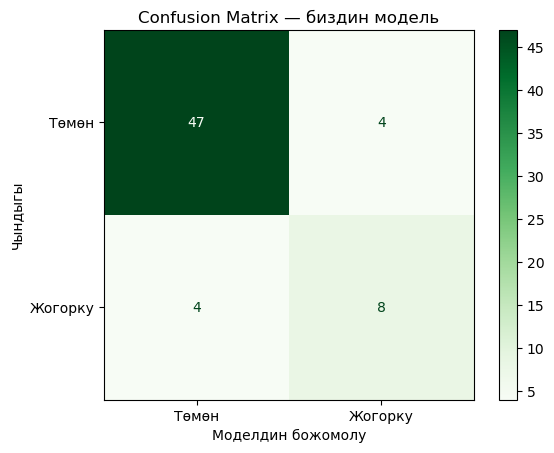

✓ TP = 8  — кооптууну туура кармадык
✓ TN = 47 — тазаны туура тынч койдук
✗ FP = 4  — ЖАЛГАН ЭСКЕРТҮҮ: таза мекемени текшерип, ресурс короттук
✗ FN = 4  — ӨТКӨРҮП ЖИБЕРҮҮ: кооптуу мекеме байкалбай калды


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_сынак, божомол)
ConfusionMatrixDisplay(cm, display_labels=["Төмөн", "Жогорку"]).plot(cmap="Greens")
plt.title("Confusion Matrix — биздин модель")
plt.xlabel("Моделдин божомолу")
plt.ylabel("Чындыгы")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✓ TP = {tp}  — кооптууну туура кармадык")
print(f"✓ TN = {tn} — тазаны туура тынч койдук")
print(f"✗ FP = {fp}  — ЖАЛГАН ЭСКЕРТҮҮ: таза мекемени текшерип, ресурс короттук")
print(f"✗ FN = {fn}  — ӨТКӨРҮП ЖИБЕРҮҮ: кооптуу мекеме байкалбай калды")

**Талкууга суроо:** Эсептөө палатасы үчүн кайсы ката жаманыраак — **FP** (бекер текшерүү) же **FN** (бузуу жашыруун бойдон калды)?

*Туура жооп жок — бул кесиптик талкуу. 2 мүнөт талкуулайлы.*

## 2-кадам · Тактыктын тузагы: «жалкоо модель»

Эксперимент: эч нерсе окубаган, **баарын «Төмөн»** дей берген моделди элестетели.

In [4]:
жалкоо_божомол = np.zeros(len(y_сынак), dtype=int)   # баары "Төмөн"

from sklearn.metrics import accuracy_score
print(f"«Жалкоо» моделдин тактыгы: {accuracy_score(y_сынак, жалкоо_божомол):.1%}")
print(f"Тапкан кооптуу мекемелери: {жалкоо_божомол.sum()}")

«Жалкоо» моделдин тактыгы: 81.0%
Тапкан кооптуу мекемелери: 0


**81% тактык — эч нерсе кылбай туруп!** 😱

Себеби: кооптуу мекемелер аз (болжол менен ар бештин бири). Баарын «таза» десең — көбүнчө «туура» чыгасың.

**Корутунду:** класстар тең эмес болгондо, тактык (accuracy) алдап коюшу мүмкүн. Ошондуктан аудитор дагы эки метриканы карайт:

## 3-кадам · Precision жана Recall

- **Precision** — модель «Жогорку» дегендердин канчасы **чын эле** кооптуу?
  *(Текшерүүгө барганда бекер убара болбоо)*
- **Recall** — бардык чын кооптуулардын канчасын **кармадык**?
  *(Аудит үчүн көбүнчө дал ушул маанилүү!)*

In [5]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_сынак, божомол)
recall = recall_score(y_сынак, божомол)

print(f"Precision: {precision:.1%} — белгилегендердин {precision:.0%}ы чын эле кооптуу")
print(f"Recall:    {recall:.1%} — бардык кооптуулардын {recall:.0%}ын кармадык")
print()
print(f"Башкача айтканда: {tp + fn} чын кооптуу мекеменин {fn}и байкалбай калды.")

Precision: 66.7% — белгилегендердин 67%ы чын эле кооптуу
Recall:    66.7% — бардык кооптуулардын 67%ын кармадык

Башкача айтканда: 12 чын кооптуу мекеменин 4и байкалбай калды.


## 4-кадам · 🖊 СИЗДИН ЭКСПЕРИМЕНТ: босогону (threshold) жылдырыңыз

Модель ар бир мекемеге ыктымалдуулук берет (мис. 62%). Стандарт эреже: **50%дан жогору → «Жогорку»**.

Бирок ким айтты 50% деп? Босогону **биз** тандайбыз!

**Тапшырма:** төмөндө `босого = 0.5` деген санды `0.3` кылып өзгөртүп, блокту кайра иштетиңиз.
Эмне өзгөрөт — FN менен FPга көңүл буруңуз.

## 5-кадам · Корутунду

Босогону 0.3кө түшүргөндө: **өткөрүп жиберүү (FN) азайды, бирок жалган эскертүү (FP) көбөйдү** — текшерүүгө көбүрөөк мекеме сунушталды.

**Негизги ой:** Босогону кайда коюу — канча ресурсубуз бар, кайсы ката кымбатыраак — бул **математиканын эмес, ЖЕТЕКЧИЛИКТИН чечими.** Модель — курал; чечим — адамдыкы.

**→ Акыркы дептер: `3_regressiya.ipynb`**

In [10]:
босого = 0.5     # 🖊 БУЛ САНДЫ ӨЗГӨРТҮҢҮЗ: 0.5 → 0.3 (андан кийин 0.7 менен да ойноп көрүңүз)

жаңы_божомол = (ыктымалдуулук >= босого).astype(int)
cm2 = confusion_matrix(y_сынак, жаңы_божомол)
tn2, fp2, fn2, tp2 = cm2.ravel()

print(f"Босого = {босого}")
print(f"  Кармадык (TP): {tp2}   Өткөрдүк (FN): {fn2}")
print(f"  Жалган эскертүү (FP): {fp2}   Текшерүүгө сунушталган мекеме: {tp2 + fp2}")
print(f"  Recall: {recall_score(y_сынак, жаңы_божомол):.1%}   Precision: {precision_score(y_сынак, жаңы_божомол):.1%}")

Босого = 0.5
  Кармадык (TP): 8   Өткөрдүк (FN): 4
  Жалган эскертүү (FP): 4   Текшерүүгө сунушталган мекеме: 12
  Recall: 66.7%   Precision: 66.7%


In [11]:
босого = 0.7     # 🖊 БУЛ САНДЫ ӨЗГӨРТҮҢҮЗ: 0.5 → 0.3 (андан кийин 0.7 менен да ойноп көрүңүз)

жаңы_божомол = (ыктымалдуулук >= босого).astype(int)
cm2 = confusion_matrix(y_сынак, жаңы_божомол)
tn2, fp2, fn2, tp2 = cm2.ravel()

print(f"Босого = {босого}")
print(f"  Кармадык (TP): {tp2}   Өткөрдүк (FN): {fn2}")
print(f"  Жалган эскертүү (FP): {fp2}   Текшерүүгө сунушталган мекеме: {tp2 + fp2}")
print(f"  Recall: {recall_score(y_сынак, жаңы_божомол):.1%}   Precision: {precision_score(y_сынак, жаңы_божомол):.1%}")

Босого = 0.7
  Кармадык (TP): 8   Өткөрдүк (FN): 4
  Жалган эскертүү (FP): 4   Текшерүүгө сунушталган мекеме: 12
  Recall: 66.7%   Precision: 66.7%


In [9]:
босого = 0.3      # 🖊 БУЛ САНДЫ ӨЗГӨРТҮҢҮЗ: 0.5 → 0.3 (андан кийин 0.7 менен да ойноп көрүңүз)

жаңы_божомол = (ыктымалдуулук >= босого).astype(int)
cm2 = confusion_matrix(y_сынак, жаңы_божомол)
tn2, fp2, fn2, tp2 = cm2.ravel()

print(f"Босого = {босого}")
print(f"  Кармадык (TP): {tp2}   Өткөрдүк (FN): {fn2}")
print(f"  Жалган эскертүү (FP): {fp2}   Текшерүүгө сунушталган мекеме: {tp2 + fp2}")
print(f"  Recall: {recall_score(y_сынак, жаңы_божомол):.1%}   Precision: {precision_score(y_сынак, жаңы_божомол):.1%}")

Босого = 0.3
  Кармадык (TP): 10   Өткөрдүк (FN): 2
  Жалган эскертүү (FP): 5   Текшерүүгө сунушталган мекеме: 15
  Recall: 83.3%   Precision: 66.7%
